# Monte-Carlo Phase Screens

This demo generates a phase screen based on the Fourier Transform method with subharmonics (random draws)

Previous methods only address propagation within a vacuum. However, it is also useful to consider a turbulent media. Earth's refractive index $n$ is nearly 1, so a slight modification to `ang_spec_multi_prop_vac` (located in optprop.prop module) function can be made.

Unfortunately, the atmospheric properties evolves **randomly** in space and time. However, it can be modelled statistically. We will also need to consider proper sampling.

The equation for vacuum propagation is as follows:

\begin{equation}
U(\bold{r}_n) = Q\left[\frac{m_{n-1}-1}{m_{n-1}\Delta z_{n-1}},\bold{r}_n\right]\prod_{i=1}^{n-1}
\left\{
    \mathcal{A}[\bold{r}_{i+1}]
    \mathcal{F}^{-1}\left[\bold{f}_i,\frac{\bold{r}_{i+1}}{m_i}\right]
    \mathcal{Q}_2\left[-\frac{\Delta z_i}{m_i},\bold{f}_i\right]
    \mathcal{F}[\bold{r}_i,\bold{f}_i]
    \frac{1}{m_i}
\right\}
\left\{
    \mathcal{Q}\left[\frac{1-m_1}{\Delta z_1},\bold{r}_1\right]
    U(\bold{r}_1)
\right\}
\end{equation}

And the algorithm for the turbulent media is defined as (also defined as the split step beam propagation method):

\begin{equation}
U(\bold{r}_n) = Q\left[\frac{m_{n-1}-1}{m_{n-1}\Delta z_{n-1}},\bold{r}_n\right]\prod_{i=1}^{n-1}
\left\{
    \mathcal{T}[z_i,z_{i+1}]
    \mathcal{F}^{-1}\left[\bold{f}_i,\frac{\bold{r}_{i+1}}{m_i}\right]
    \mathcal{Q}_2\left[-\frac{\Delta z_i}{m_i},\bold{f}_i\right]
    \mathcal{F}[\bold{r}_i,\bold{f}_i]
    \frac{1}{m_i}
\right\}
\left\{
    \mathcal{Q}\left[\frac{1-m_1}{\Delta z_1},\bold{r}_1\right]
    \mathcal{T}[z_1,z_2]
    U(\bold{r}_1)
\right\}
\end{equation}

The notable difference here is the replacement of the absorption boundary $\mathcal{A}$ (previous example uses the super gaussian window) and the addition of the accumulation in phase operator $\mathcal{T}$. Note that, if $\mathcal{T} = 1$ at every step, you'd get the vacuum propagation algorithm again.
$$
    \mathcal{T}[z_i,z_{i+1}] =  e^{-i\phi(\bold{r}_{i+1})}
$$

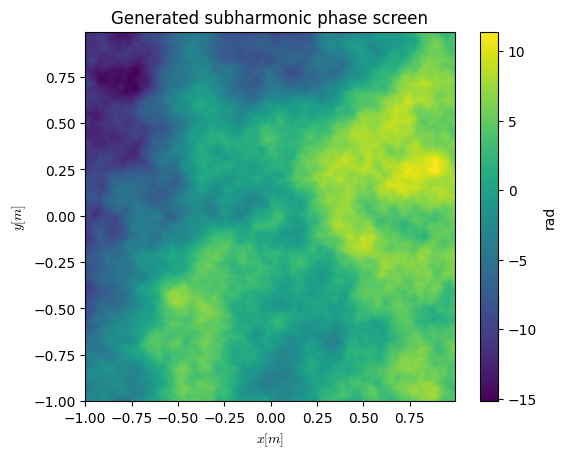

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from optprop.media import ft_sh_phase_screen

np.random.seed(1)

D = 2
r0 = 0.1
N = 256
L0 = 100
l0 = 0.01

delta = D/N
x = np.arange(-N/2,N/2,1) * delta
y = x
phz_lo,phz_hi = ft_sh_phase_screen(r0,N,delta,L0,l0)
phz = phz_lo + phz_hi

fig,ax = plt.subplots()
im = ax.imshow(phz,extent=[x[0],x[-1],y[0],y[-1]])
fig.colorbar(im,label="rad")
ax.set_xlabel(r"$x[m]$",math_fontfamily='cm')
ax.set_ylabel(r"$y[m]$",math_fontfamily='cm')
ax.set_title("Generated subharmonic phase screen")
plt.show()